In [52]:
%load_ext autoreload
%autoreload 2
import jax
import jax.numpy as jnp

from sklearn.datasets import make_s_curve, make_blobs
import sklearn

import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

from jax.example_libraries import stax

import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro import optim
from numpyro.infer import Predictive
from numpyro import handlers



from numpyro.contrib.einstein import RBFKernel
from CustomModules.mixture_guide_impl_source import MixtureGuidePredictive
from CustomModules.stein_impl_source import SteinVI
from CustomModules.single_site_rbf import SingleSiteRBFKernel
from CustomModules.architectures import *
from CustomModules.moving_reduce import moving_reduce


from morbius import make_mobius_strip
from checker import make_nd_checkerboard
rng_key = jax.random.key(42)

from CustomModules.normalizing_flow import normalizing_flow

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [53]:
def plot3d(d, title):
    d = d.reshape(-1, 3)
    fig = px.scatter_3d(x=d[:,0], y=d[:,1], z=d[:,2], title=title)
    fig.update_traces(marker=dict(size=2))


    fig.update_layout(
        title_text=title,
        title_x=0.5,              
        title_y=0.95,               
        title_font_family="Arial",  
        title_font_size=24,        
        title_font_color="navy",     
        margin=dict(t=60)            
    )

    fig.show()


In [54]:
X_blobs, _=  make_blobs(centers=2,n_features=3, cluster_std=0.5, random_state=0, n_samples=1000)
plot3d(X_blobs, "Blob Data")

In [55]:

def encoder(hidden_dim, z_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.FanOut(2),
        stax.parallel(
            stax.Dense(z_dim, W_init=stax.randn()),
            stax.serial(stax.Dense(z_dim, W_init=stax.randn()), stax.Exp),
        ),
    )


def decoder(hidden_dim, out_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(out_dim, W_init=stax.randn()),
    )



In [56]:
X = X_blobs

batch_size = X.shape[0]
dataloader = [X[i:i+batch_size] for i in range(0, len(X), batch_size)]

out_dim = X.reshape(X.shape[0], -1).shape[1]

hidden_dim = 8
z_dim = 2
lr=5e-4
adam = optim.Adam(lr)


encoder_args = {"hidden_dim": hidden_dim, "z_dim": z_dim}
decoder_args = {"hidden_dim": hidden_dim, "out_dim": out_dim}

num_epochs = 20000


# Global Stein

In [57]:
def plot_vae(vae, rng_key, share_axis=True):
    rng_key, e_sub, d_sub, s_sub = jax.random.split(rng_key, 4)

    values = vae.encode_batch(X, e_sub)
    X_recon = vae.decode_latent({"z": values["z"], "m": values["m"]}, d_sub)

    has_m = values.get("m") is not None
    c_recon = values.get("pidx")

    plot3d(X_recon["obs"], "recon")

    fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=share_axis, sharey=share_axis)

    for ax in axes.flat:
        ax.set_aspect('equal')

    axes[0, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_recon)
    axes[0, 0].set_title("recon latent (z)")

    if has_m:
        axes[0, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_recon)
        axes[0, 1].set_title("recon latent (m)")
    else:
        axes[0, 1].axis("off")

    values = vae.sample(s_sub, 1000)
    plot3d(values["obs"], "samples")

    c_samp = values.get("pidx")

    axes[1, 0].scatter(values["z"][:, 0], values["z"][:, 1], c=c_samp)
    axes[1, 0].set_title("samples latent (z)")

    if has_m:
        axes[1, 1].scatter(values["m"][:, 0], values["m"][:, 1], c=c_samp)
        axes[1, 1].set_title("samples latent (m)")
    else:
        axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()

In [58]:
rng_key, sub_key = jax.random.split(rng_key)

stein_global_vae = SteinGlobalVAE(encoder, encoder_args, decoder, decoder_args, z_dim, normal_scale=0.5)

per_particle_norms_stein_global = stein_global_vae.train(dataloader, X.shape[0], adam, num_epochs, sub_key, 5, repulsion_temperature=1, num_elbo_particles=20)




  0%|          | 0/20000 [00:00<?, ?it/s]E0505 14:19:16.967837   10048 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0505 14:19:17.169802   10057 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
Epoch 19999, Loss: 13.18: 100%|██████████| 20000/20000 [02:56<00:00, 113.45it/s]


Ran with 20000 batches


In [59]:
# save the norms for later analysis
# import pickle
# with open("stein_particle_norms_stein_global.pkl", "wb") as f:
#     pickle.dump(per_particle_norms_stein_global, f)

#Loading norms from file
# import pickle
# with open("stein_particle_norms.pkl", "rb") as f:
#     per_particle_norms = pickle.load(f)

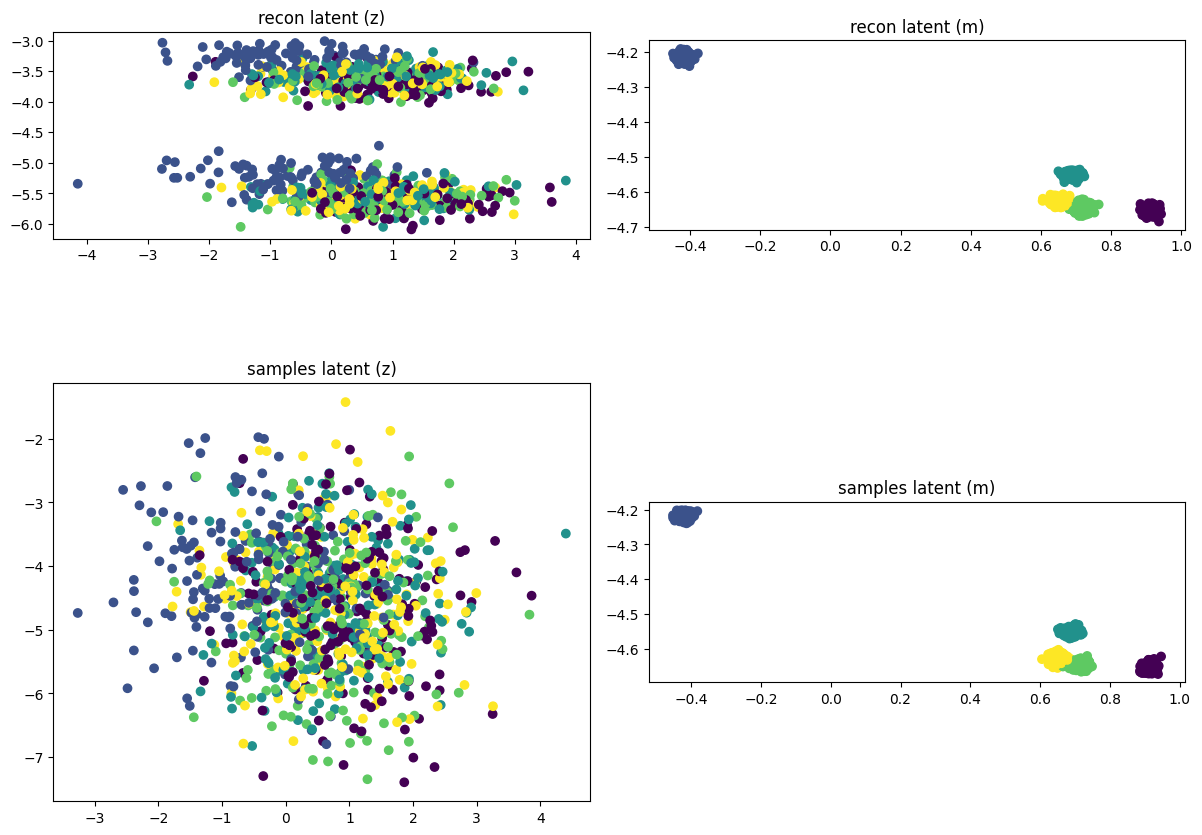

In [60]:
plot_vae(stein_global_vae, sub_key, False)

# SMI VAE 74

In [61]:
def plot_smi_vae(vae, rng_key):
    rng_key, e_sub, d_sub, s_sub = jax.random.split(rng_key, 4)

    values = vae.encode_batch(X, e_sub)
    X_recon = vae.decode_latent({key:value  for key, value in values.items() if "z" in key or key == "m"}, d_sub, size_site="z0")

    plot3d(X_recon["obs"], "recon")


    values = vae.sample(s_sub, 3000)
    plot3d(values["obs"], "samples")


In [62]:
def f_shared(hidden_dim, f_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
    )

def g(z_dim, variance_floor=0.1):
    SafeSoftplus = stax.elementwise(lambda x: jnp.clip(stax.softplus(x-3.0), a_min=0.0, a_max=20.0) + variance_floor)
    return stax.serial(
        stax.FanOut(2),
        stax.parallel(
            stax.serial(stax.Dense(z_dim), stax.elementwise(lambda x: jnp.clip(x, -10.0, 10.0))),
            stax.serial(stax.Dense(z_dim), SafeSoftplus),
        )
    )

def h(hidden_dim, h_dim):
    return stax.serial(
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
        stax.Dense(hidden_dim, W_init=stax.randn()),
        stax.Softplus,
    )

In [63]:
rng_key, sub_key = jax.random.split(rng_key)
f_args = {"hidden_dim": hidden_dim, "f_dim": z_dim}
g_args = {"z_dim": z_dim}
h_args = {"hidden_dim": hidden_dim, "h_dim": z_dim}
flow_args = {"input_dim": z_dim, "hidden_dims": [5, 5], "steps": 0, "inv": True}
m_dim = z_dim
smivae74 = SMIVAE74(decoder, decoder_args, f_shared, f_args, h, h_args, g, g_args, g, g_args, 4, z_dim, m_dim, normalizing_flow, flow_args, normal_scale=0.5)
per_particle_norms_smi74 = smivae74.train(dataloader, len(X), adam, num_epochs=num_epochs, rng_key=sub_key, num_stein_particles=5, annealing_epochs=1, num_elbo_particles=20) # Annealing disabled

Epoch 19999, Loss: 2.92: 100%|██████████| 20000/20000 [09:56<00:00, 33.52it/s] 


Ran with 20000 batches


In [64]:
# #save the norms for later analysis
# import pickle
# with open("stein_particle_norms_smi74.pkl", "wb") as f:
#     pickle.dump(per_particle_norms_smi74, f)

# #Loading norms from file
# # import pickle
# # with open("stein_particle_norms_smi74.pkl", "rb") as f:
# #     per_particle_norms = pickle.load(f)

In [65]:
rng_key, sub_key = jax.random.split(rng_key)
plot_smi_vae(smivae74, sub_key)

# Analysis

In [66]:
import numpy as np
import matplotlib.pyplot as plt

def plot_stein_norms(per_particle_norms, title, iteration_slice=slice(None)):
    norms = np.asarray(jax.device_get(per_particle_norms))

    # norms shape: [iterations, particles]
    norms = norms[iteration_slice]

   

    iterations = np.arange(norms.shape[0])

    if iteration_slice.start is not None:
        iterations = iterations + iteration_slice.start

    mean_norm = norms.mean(axis=1)
    std_norm = norms.std(axis=1)
    max_norm = norms.max(axis=1)

    eps = 1e-12
    norms = np.maximum(norms, eps)
    mean_norm = np.maximum(mean_norm, eps)
    std_norm = np.maximum(std_norm, eps)
    max_norm = np.maximum(max_norm, eps)

    plt.figure(figsize=(14, 5))


    plt.semilogy(iterations, mean_norm, linewidth=2, label="mean")
    plt.semilogy(iterations, max_norm, linewidth=2, linestyle="--", label="max")
    plt.fill_between(iterations, mean_norm - std_norm, mean_norm + std_norm, color='blue', alpha=0.2, label="std")

    plt.xlabel("Iteration")
    plt.ylabel("Stein particle norm")
    plt.title(title)
    plt.legend()
    fig = plt.gcf()
    plt.show()
    return fig



def plot_individual_paths(per_particle_norms, title, iteration_slice=slice(None), window=3):

    norms = np.asarray(jax.device_get(per_particle_norms))

    # norms shape: [iterations, particles]
    norms = norms[iteration_slice]

    # add smoothing with a lag of 3 for each path
    norms =np.apply_along_axis(lambda m: np.convolve(m, np.ones(window)/window, mode='same'), axis=0, arr=norms)




    iterations = np.arange(norms.shape[0])

    if iteration_slice.start is not None:
        iterations = iterations + iteration_slice.start

    plt.figure(figsize=(14, 5))

    for i in range(norms.shape[1]):
        plt.semilogy(iterations, norms[:, i], linewidth=1, label=f"particle {i}")

    plt.xlabel("Iteration")
    plt.ylabel("Stein particle norm")
    plt.title(title)
    plt.legend()
    fig = plt.gcf()
    plt.show()

    # return image:
    return fig


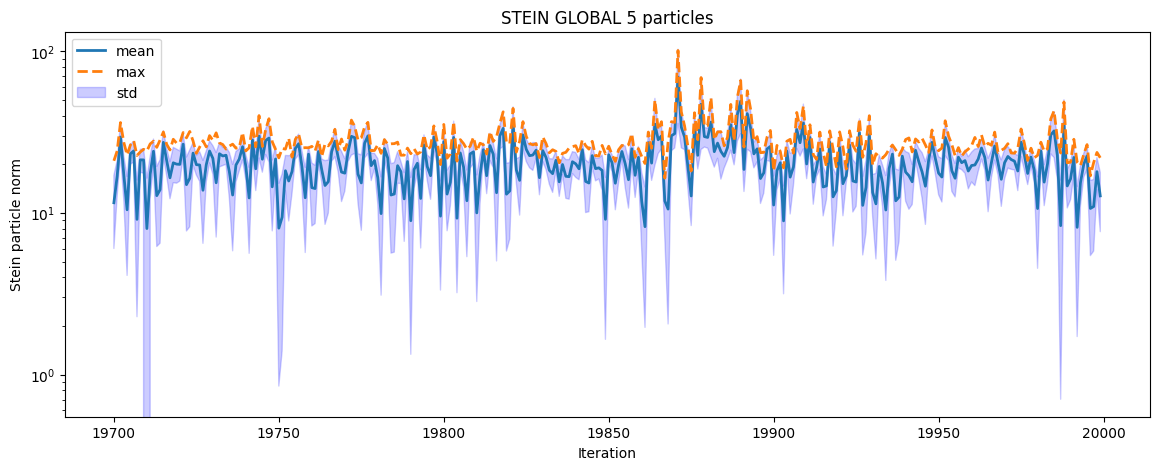

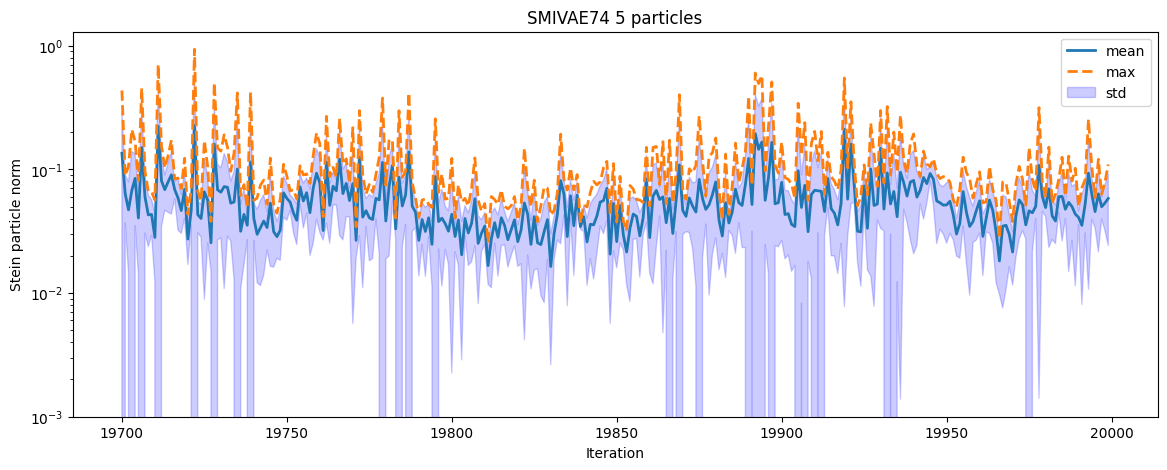

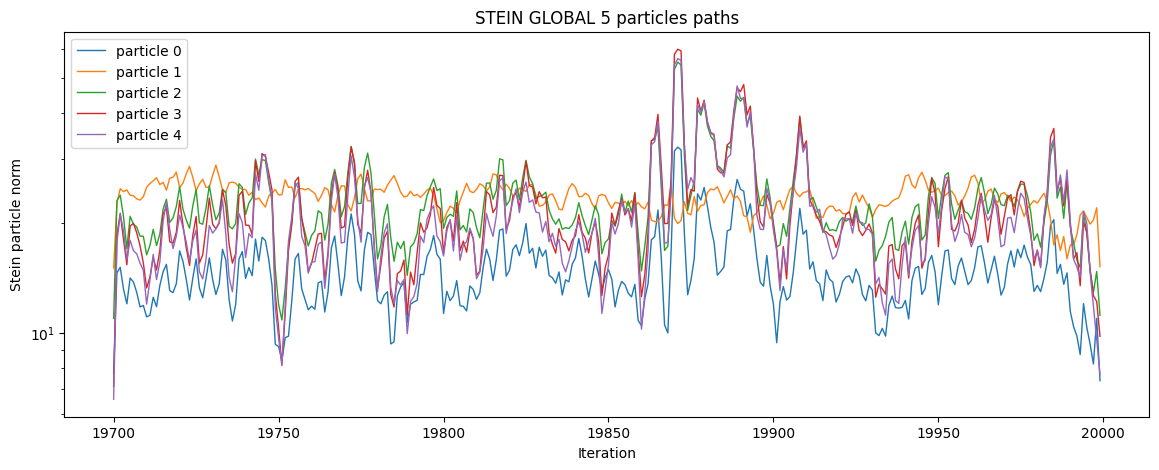

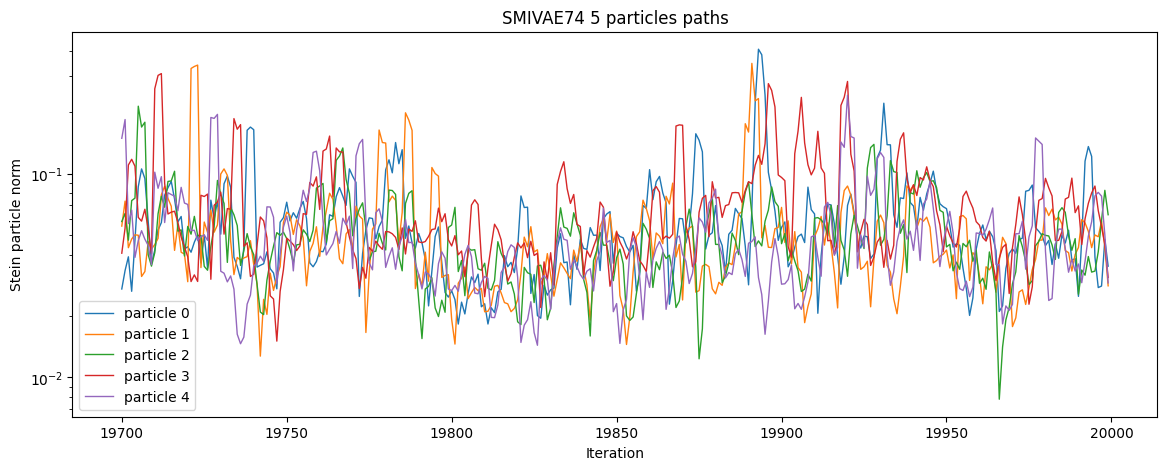

In [67]:
stein_global_stats = plot_stein_norms(per_particle_norms_stein_global, "STEIN GLOBAL 5 particles", slice(num_epochs-300, num_epochs))
smi74_stats = plot_stein_norms(per_particle_norms_smi74, "SMIVAE74 5 particles", slice(num_epochs-300, num_epochs))
stein_global_paths = plot_individual_paths(per_particle_norms_stein_global, "STEIN GLOBAL 5 particles paths", slice(num_epochs-300, num_epochs))
smi74_paths = plot_individual_paths(per_particle_norms_smi74, "SMIVAE74 5 particles paths", slice(num_epochs-300, num_epochs))

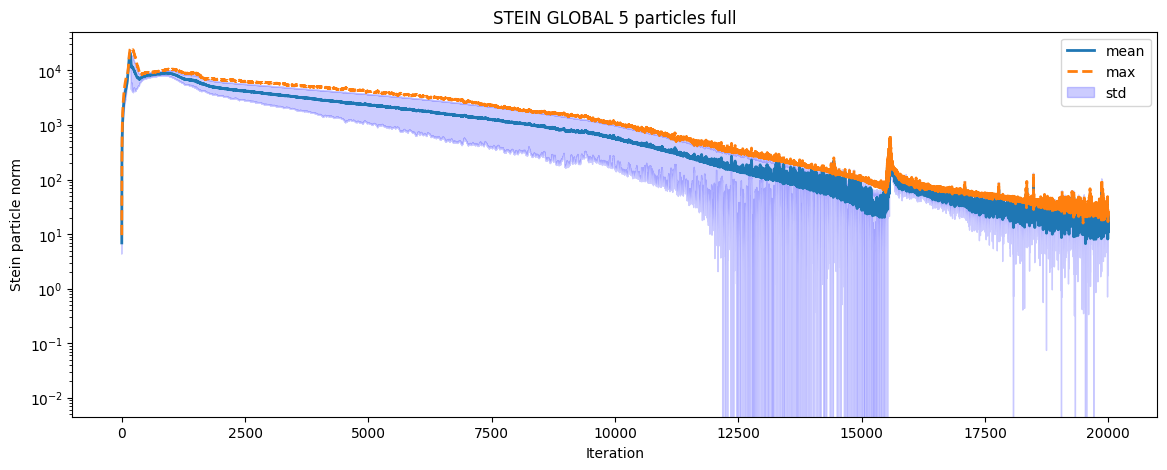

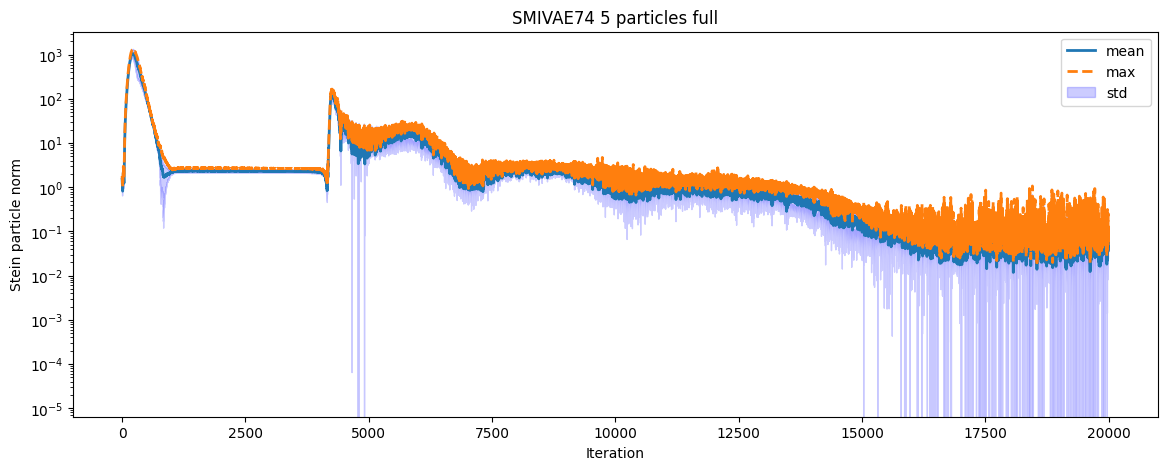

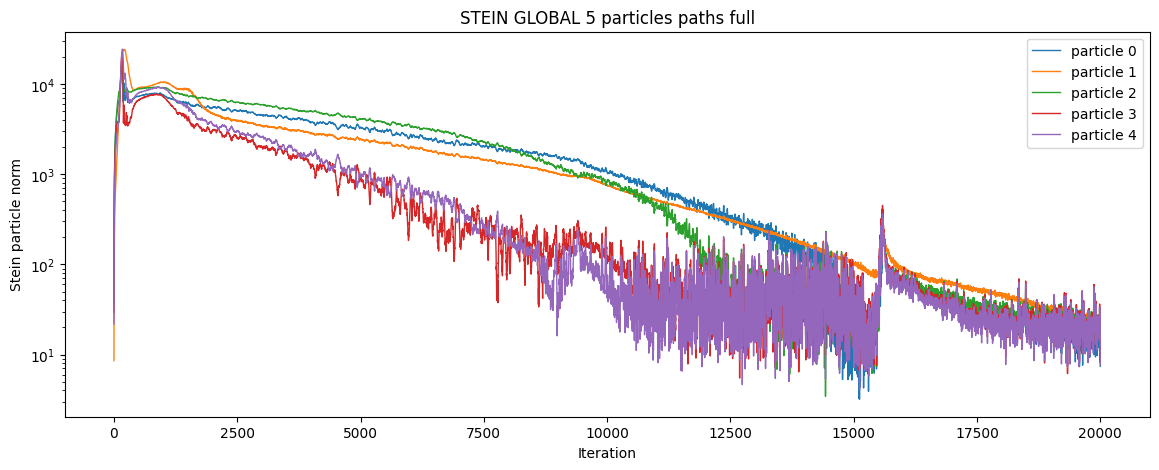

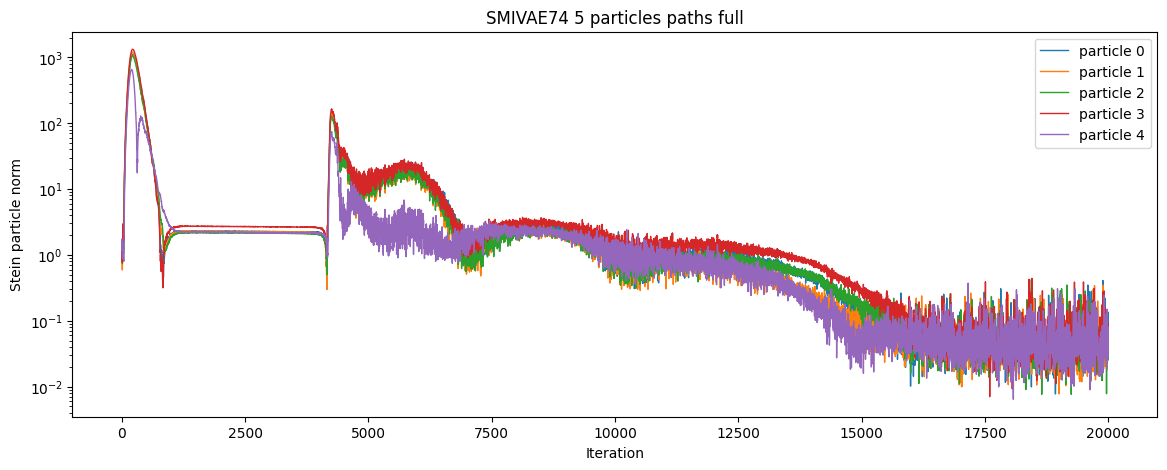

In [68]:
stein_global_stats_full = plot_stein_norms(per_particle_norms_stein_global, "STEIN GLOBAL 5 particles full", slice(0, num_epochs))
smi74_stats_full = plot_stein_norms(per_particle_norms_smi74, "SMIVAE74 5 particles full", slice(0, num_epochs))
stein_global_paths_full = plot_individual_paths(per_particle_norms_stein_global, "STEIN GLOBAL 5 particles paths full", slice(0, num_epochs))
smi74_paths_full = plot_individual_paths(per_particle_norms_smi74, "SMIVAE74 5 particles paths full", slice(0, num_epochs))

In [69]:
def chapter(txt):
    plt.figure(figsize=(14, 5))
    plt.text(0.5, 0.5, txt, fontsize=24, ha='center', va='center')
    plt.axis('off')
    fig = plt.gcf()
    plt.close()
    return fig

In [70]:
# add all those plots to pdf:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
with PdfPages("stein_norm_convergence_plots.pdf") as pdf:


    pdf.savefig(chapter(f"Zoomed in (iterations {num_epochs-300}-{num_epochs})"))

    pdf.savefig(stein_global_stats)
    pdf.savefig(smi74_stats)
    pdf.savefig(stein_global_paths)
    pdf.savefig(smi74_paths)


    pdf.savefig(chapter(f"Full range (iterations 0-{num_epochs})")) 
    
    pdf.savefig(stein_global_stats_full)
    pdf.savefig(smi74_stats_full)
    pdf.savefig(stein_global_paths_full)
    pdf.savefig(smi74_paths_full)
